# Fake News Detection: XGBoost & LSTM

**Setup complete!** CSV files are already uploaded to `/content/`.

**Steps:**
1. Go to `Runtime → Change runtime type` and set Hardware accelerator to **GPU (T4)** for 10x faster LSTM training
2. Run all cells in order

In [ ]:
# Install dependencies
!pip install -q xgboost scikit-learn tensorflow matplotlib seaborn numpy pandas

In [ ]:
import re
import warnings
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

SEED = 42
warnings.filterwarnings("ignore")

In [ ]:
# Config
DATA_DIR = Path("/content")
RESULTS_DIR = Path("/content/results")
RESULTS_DIR.mkdir(exist_ok=True)

WELFAKE_PATH  = DATA_DIR / "WELFake_Dataset.csv"
RECOVERY_PATH = DATA_DIR / "recovery-news-data.csv"

# Model hyperparameters — tweak here if needed
MAX_FEATURES    = 25000   # TF-IDF vocab size
NGRAM_MAX       = 1
MAX_WORDS       = 20000   # LSTM tokenizer vocab
MAX_LEN         = 200     # Sequence length
LSTM_EPOCHS     = 6
LSTM_BATCH_SIZE = 96

DEFAULT_SOURCE_TERMS = [
    "reuters", "associated press", "ap news", "cnn", "fox news",
    "new york times", "washington post", "bbc", "nbc news",
]

print("Paths set. Checking files exist...")
print("WELFake exists:",  WELFAKE_PATH.exists())
print("Recovery exists:", RECOVERY_PATH.exists())

Paths set. Checking files exist...
WELFake exists: True
Recovery exists: True


In [ ]:
# Preprocessing

def _compile_block_pattern(blocked_terms: Iterable[str]) -> Optional[str]:
    cleaned = [
        re.escape(t.strip().lower())
        for t in blocked_terms
        if t and t.strip()
    ]
    if not cleaned:
        return None

    phrase_pattern = "|".join(t.replace(r"\ ", r"\s+") for t in cleaned)
    return rf"\b(?:{phrase_pattern})\b"


def normalize_text(series: pd.Series, blocked_terms: Optional[Iterable[str]] = None) -> pd.Series:
    series = series.fillna("").astype(str).str.lower()

    series = series.str.replace(r"https?://\S+|www\.\S+", " ", regex=True)
    series = series.str.replace(r"[^a-z0-9\s]", " ", regex=True)

    block_pattern = _compile_block_pattern(blocked_terms or [])
    if block_pattern:
        series = series.str.replace(block_pattern, " ", regex=True)

    return series.str.replace(r"\s+", " ", regex=True).str.strip()

def load_welfake(path: Path, blocked_terms=None) -> pd.DataFrame:
    df = pd.read_csv(path, on_bad_lines='skip', engine='python')

    # safety check (prevents silent crash if schema differs)
    required = {"title", "text", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"WELFake missing columns: {missing}")

    df["title"] = normalize_text(df["title"], blocked_terms)
    df["text"]  = normalize_text(df["text"], blocked_terms)

    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df[df["label"].isin([0, 1])].copy()

    df["label"] = df["label"].astype(int)
    df["input_text"] = (df["title"] + " " + df["text"]).str.strip()

    return df[df["input_text"].str.len() > 0][["input_text", "label"]].reset_index(drop=True)


def load_recovery(path: Path, blocked_terms=None) -> pd.DataFrame:
    df = pd.read_csv(path, on_bad_lines='skip', engine='python')

    required = {"title", "body_text", "reliability"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Recovery dataset missing columns: {missing}")

    df["title"]     = normalize_text(df["title"], blocked_terms)
    df["body_text"] = normalize_text(df["body_text"], blocked_terms)

    df["reliability"] = pd.to_numeric(df["reliability"], errors="coerce")
    df = df[df["reliability"].isin([0, 1])].copy()

    df["label"] = df["reliability"].astype(int)
    df["input_text"] = (df["title"] + " " + df["body_text"]).str.strip()

    return df[df["input_text"].str.len() > 0][["input_text", "label"]].reset_index(drop=True)

welfake_df = load_welfake(WELFAKE_PATH, blocked_terms=DEFAULT_SOURCE_TERMS)
recovery_df = load_recovery(RECOVERY_PATH, blocked_terms=DEFAULT_SOURCE_TERMS)

print(f"WELFake:  {len(welfake_df):,} rows")
print(f"Recovery: {len(recovery_df):,} rows")

Loading datasets...
WELFake:  72,110 rows
Recovery: 2,029 rows


In [ ]:
# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    welfake_df["input_text"],
    welfake_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=welfake_df["label"],
)
y_recovery = recovery_df["label"]
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Recovery: {len(y_recovery):,}")

Train: 57,688  |  Val: 14,422  |  Recovery: 2,029


In [ ]:
# Metrics helpers
def compute_metrics(y_true, y_pred) -> dict:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return {
        "accuracy":         float(accuracy_score(y_true, y_pred)),
        "precision":        float(precision),
        "recall":           float(recall),
        "f1":               float(f1),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }


def compute_label_balance(y_series) -> dict:
    total = len(y_series)
    fake  = int((y_series == 0).sum())
    real  = int((y_series == 1).sum())
    return {
        "total":        total,
        "fake_count":   fake,
        "real_count":   real,
        "fake_percent": round(100.0 * fake / total, 2),
        "real_percent": round(100.0 * real / total, 2),
    }


def detect_overfitting(welfake_metrics, recovery_metrics, model_name) -> dict:
    val_acc      = welfake_metrics["accuracy"]
    recovery_acc = recovery_metrics["accuracy"]
    drop         = val_acc - recovery_acc
    return {
        "model":               model_name,
        "welfake_accuracy":    round(val_acc, 4),
        "recovery_accuracy":   round(recovery_acc, 4),
        "accuracy_drop":       round(drop, 4),
        "welfake_f1":          round(welfake_metrics["f1"], 4),
        "recovery_f1":         round(recovery_metrics["f1"], 4),
        "overfitting_severity": "SEVERE" if drop > 0.30 else "MODERATE" if drop > 0.15 else "LOW",
    }


def plot_model_metrics(model_name: str, model_results: dict):
    metric_names  = ["accuracy", "precision", "recall", "f1"]
    val_values      = [float(model_results["welfake_validation_20pct"][m]) for m in metric_names]
    recovery_values = [float(model_results["recovery_external_test"][m])   for m in metric_names]
    x, width = np.arange(len(metric_names)), 0.36
    plt.figure(figsize=(8, 5))
    plt.bar(x - width / 2, val_values,      width=width, label="WELFake holdout")
    plt.bar(x + width / 2, recovery_values, width=width, label="Recovery external")
    plt.xticks(x, [m.upper() for m in metric_names])
    plt.ylim(0.0, 1.05)
    plt.ylabel("Score")
    plt.title(f"{model_name} Performance: Holdout vs External")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{model_name.lower()}_metrics.png", dpi=150)
    plt.show()

print("Helpers defined.")

Helpers defined.


Training XGBoost...
XGBoost done.
  WELFake val  — Acc: 0.8893  F1: 0.8922
  Recovery     — Acc: 0.3958  F1: 0.5024
  Overfitting: SEVERE (drop: 0.4935)


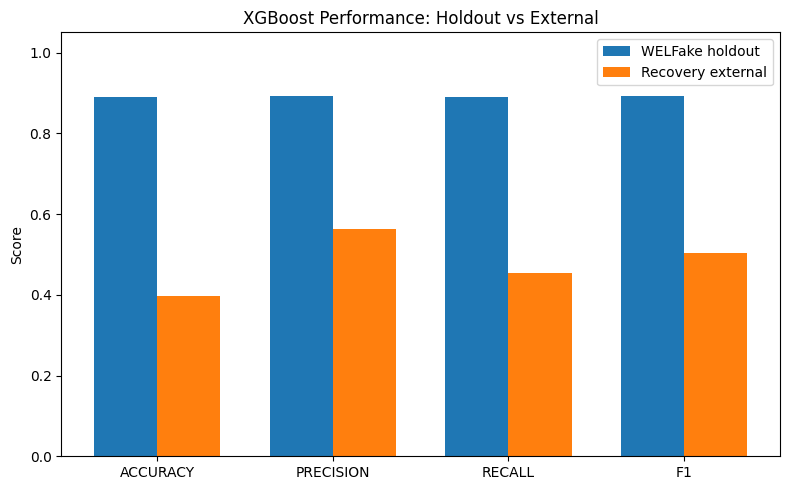

In [ ]:
# XGBoost

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, NGRAM_MAX),
    min_df=5,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
)
X_train_vec    = vectorizer.fit_transform(X_train)
X_val_vec      = vectorizer.transform(X_val)
X_recovery_vec = vectorizer.transform(recovery_df["input_text"])

xgb_model = XGBClassifier(
    n_estimators=180, learning_rate=0.05, max_depth=3,
    min_child_weight=5, gamma=1.0, subsample=0.65,
    colsample_bytree=0.6, reg_alpha=0.5, reg_lambda=2.0,
    objective="binary:logistic", eval_metric="logloss",
    random_state=SEED, n_jobs=-1,
)
xgb_model.fit(X_train_vec, y_train)

xgboost_results = {
    "welfake_validation_20pct": compute_metrics(y_val,       xgb_model.predict(X_val_vec)),
    "recovery_external_test":   compute_metrics(y_recovery,  xgb_model.predict(X_recovery_vec)),
}
xgb_overfitting = detect_overfitting(
    xgboost_results["welfake_validation_20pct"],
    xgboost_results["recovery_external_test"],
    "XGBoost",
)

print("XGBoost done.")
print(f"  WELFake val  — Acc: {xgboost_results['welfake_validation_20pct']['accuracy']:.4f}  F1: {xgboost_results['welfake_validation_20pct']['f1']:.4f}")
print(f"  Recovery     — Acc: {xgboost_results['recovery_external_test']['accuracy']:.4f}  F1: {xgboost_results['recovery_external_test']['f1']:.4f}")
print(f"  Overfitting: {xgb_overfitting['overfitting_severity']} (drop: {xgb_overfitting['accuracy_drop']})")
plot_model_metrics("XGBoost", xgboost_results)

Training LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
601/601 ━━━━━━━━━━━━━━━━━━━━ 857s 1s/step - accuracy: 0.8987 - loss: 0.2509 - val_accuracy: 0.9336 - val_loss: 0.1712 - learning_rate: 8.0000e-04
Epoch 2/6
601/601 ━━━━━━━━━━━━━━━━━━━━ 848s 1s/step - accuracy: 0.9602 - loss: 0.1206 - val_accuracy: 0.9508 - val_loss: 0.1355 - learning_rate: 8.0000e-04
Epoch 3/6
601/601 ━━━━━━━━━━━━━━━━━━━━ 841s 1s/step - accuracy: 0.9730 - loss: 0.0845 - val_accuracy: 0.9543 - val_loss: 0.1356 - learning_rate: 8.0000e-04
Epoch 4/6
601/601 ━━━━━━━━━━━━━━━━━━━━ 863s 1s/step - accuracy: 0.9841 - loss: 0.0531 - val_accuracy: 0.9574 - val_loss: 0.1336 - learning_rate: 4.0000e-04
Epoch 5/6
601/601 ━━━━━━━━━━━━━━━━━━━━ 940s 1s/step - accuracy: 0.9876 - loss: 0.0418 - val_accuracy: 0.9567 - val_loss: 0.1467 - learning_rate: 4.0000e-04
Epoch 6/6
601/601 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.9920 - loss: 0.0296 - val_accuracy: 0.9591 - val_loss: 0.1614 - learning_rate: 2.0000e-04

Decision threshold: 0.35
  WELFake val  — Acc: 0.9580  F1: 0.95

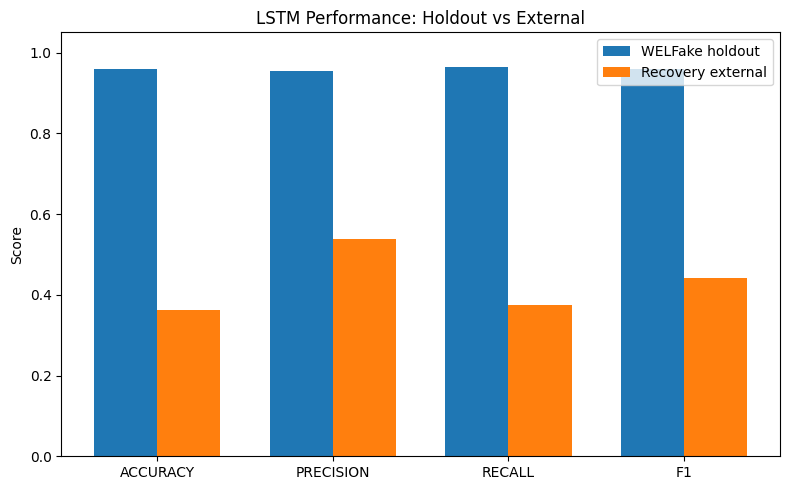

In [ ]:
# LSTM

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return tf.keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=MAX_LEN, padding="post", truncating="post"
    )

X_train_pad    = encode(X_train)
X_val_pad      = encode(X_val)
X_recovery_pad = encode(recovery_df["input_text"])

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=96),
    tf.keras.layers.SpatialDropout1D(0.25),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(48, dropout=0.3, recurrent_dropout=0.2)),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

y_train_np = np.asarray(y_train)
cw_raw = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train_np)
class_weight = {0: float(cw_raw[0]), 1: float(cw_raw[1])}

history = model.fit(
    X_train_pad, y_train_np,
    validation_data=(X_val_pad, np.asarray(y_val)),
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5),
    ],
    class_weight=class_weight,
    verbose=1,
)

# Find best F1 threshold
val_probs      = model.predict(X_val_pad,      batch_size=256, verbose=0).ravel()
recovery_probs = model.predict(X_recovery_pad, batch_size=256, verbose=0).ravel()

best_threshold, best_f1 = 0.5, -1.0
for thr in np.arange(0.35, 0.66, 0.01):
    score = f1_score(np.asarray(y_val), (val_probs >= thr).astype(int), zero_division=0)
    if score > best_f1:
        best_f1, best_threshold = score, float(thr)

lstm_results = {
    "welfake_validation_20pct": compute_metrics(y_val,      (val_probs      >= best_threshold).astype(int)),
    "recovery_external_test":   compute_metrics(y_recovery, (recovery_probs >= best_threshold).astype(int)),
}
lstm_overfitting = detect_overfitting(
    lstm_results["welfake_validation_20pct"],
    lstm_results["recovery_external_test"],
    "LSTM",
)

print(f"\nDecision threshold: {best_threshold:.2f}")
print(f"  WELFake val  — Acc: {lstm_results['welfake_validation_20pct']['accuracy']:.4f}  F1: {lstm_results['welfake_validation_20pct']['f1']:.4f}")
print(f"  Recovery     — Acc: {lstm_results['recovery_external_test']['accuracy']:.4f}  F1: {lstm_results['recovery_external_test']['f1']:.4f}")
print(f"  Overfitting: {lstm_overfitting['overfitting_severity']} (drop: {lstm_overfitting['accuracy_drop']})")
plot_model_metrics("LSTM", lstm_results)

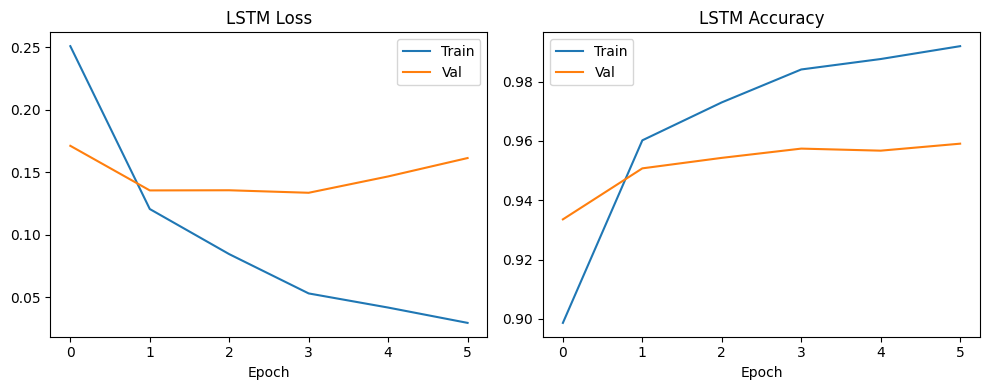

In [ ]:
# Training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"],     label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("LSTM Loss"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"],     label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("LSTM Accuracy"); plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "lstm_training_curve.png", dpi=150)
plt.show()

In [ ]:
#Results

def results_to_df(results):
    rows = []
    for dataset, metrics in results.items():
        row = {"dataset": dataset}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

# Create tables
xgb_df = results_to_df(xgboost_results)
lstm_df = results_to_df(lstm_results)

print("XGBoost Results")
display(xgb_df)

print("LSTM Results")
display(lstm_df)

XGBoost Results


,dataset,accuracy,precision,recall,f1,confusion_matrix
0,welfake_validation_20pct,0.889266,0.893442,0.890912,0.892175,"[[6218, 788], [809, 6607]]"
1,recovery_external_test,0.395761,0.562727,0.453812,0.502435,"[[184, 481], [745, 619]]"


LSTM Results


,dataset,accuracy,precision,recall,f1,confusion_matrix
0,welfake_validation_20pct,0.957981,0.954485,0.964266,0.959351,"[[6665, 341], [265, 7151]]"
1,recovery_external_test,0.362740,0.537408,0.373900,0.440986,"[[226, 439], [854, 510]]"
